# 📓 Problem 5: Handwritten Digit Recognition Web Application Using PyTorch and Flask

In this project, we build a complete end-to-end handwritten digit recognition system using deep learning, PyTorch, and Flask. Instead of stopping after training a neural network, we take the next step toward real-world AI deployment by transforming our trained MNIST digit classification model into an interactive web application.

The goal of this project is simple: given an image containing a handwritten digit, the model predicts which digit (0–9) is represented in the image.

This notebook demonstrates the complete deployment workflow:

* Loading a previously trained PyTorch model
* Preprocessing uploaded digit images
* Running predictions with the neural network
* Building a simple web interface using Flask
* Allowing users to upload handwritten digit images directly from a browser
* Returning real-time digit classification results

The project also introduces important production concepts such as:

* Model persistence using `torch.save()` and `load_state_dict()`
* Inference mode using `model.eval()`
* Consistent image preprocessing during deployment
* Web APIs and browser interaction
* Deploying AI systems through Flask applications

The handwritten digit recognition model used in this project was trained using the MNIST dataset, one of the most widely used benchmark datasets in computer vision and deep learning education. During deployment, uploaded images are resized, normalized, and transformed into the same format used during training before being passed to the neural network for prediction.

By the end of this notebook, you will have a small production-style computer vision application that users can access through a web browser. Users can upload images of handwritten digits and instantly receive predictions from the trained neural network, demonstrating how deep learning models are deployed and used in real-world environments.


# Step 1: Install Flask and Supporting Libraries

Before building the web application, we install Flask and image-processing libraries.

These libraries allow us to:

- Create a web interface using Flask
- Upload digit images from a browser
- Process images using Pillow (PIL)
- Run inference using the trained MNIST model

The web application will load the trained neural network and allow users to upload handwritten digit images for real-time prediction.

In [1]:
# ====================================================
# Step 1: Install Flask and Supporting Libraries
# ====================================================

!pip install flask pillow

# Step 2: Import Required Libraries
These libraries are used for Flask, PyTorch, threading, and generating browser-accessible URLs in Colab.

In [2]:
from flask import Flask, request
import torch
import torch.nn as nn
from PIL import Image
import numpy as np
import threading
from google.colab.output import eval_js

# Step 3: Define the MNIST Neural Network Architecture

Before loading the trained model, we must recreate the exact neural network architecture that was used during training.

This is a requirement in PyTorch because the saved file (`mnist_digit_classifier.pth`) stores only the learned model parameters (weights and biases), not the network structure itself. Therefore, the architecture used during deployment must be identical to the architecture used during training.

The MNIST classifier is a fully connected feedforward neural network designed to classify handwritten digits from the MNIST dataset. Each input image is a grayscale image of size **28 × 28 pixels**, resulting in **784 input features** after flattening.

The network consists of:

- A **Flatten Layer** that converts a 28 × 28 image into a one-dimensional vector of 784 values
- **Hidden Layer 1** with 128 neurons and ReLU activation
- **Hidden Layer 2** with 64 neurons and ReLU activation
- An **Output Layer** with 10 neurons representing the ten digit classes (0–9)

The architecture can be summarized as:

```text
28 × 28 Image
       ↓
Flatten Layer
       ↓
784 Inputs
       ↓
128 Neurons + ReLU
       ↓
64 Neurons + ReLU
       ↓
10 Output Neurons
       ↓
Digit Prediction (0–9)
```

During deployment, uploaded digit images will pass through the same sequence of transformations before the model generates a prediction. Using the exact architecture ensures that the saved weights can be loaded correctly and that inference results remain consistent with the training process.

In [6]:
# ====================================================
# Step 3: Define the MNIST Neural Network Architecture
# ====================================================

import torch
import torch.nn as nn

class MNISTClassifier(nn.Module):

    def __init__(self):

        super(MNISTClassifier, self).__init__()

        self.flatten_layer = nn.Flatten()

        self.input_to_hidden1 = nn.Linear(
            784,
            128
        )

        self.relu_activation1 = nn.ReLU()

        self.hidden1_to_hidden2 = nn.Linear(
            128,
            64
        )

        self.relu_activation2 = nn.ReLU()

        self.hidden2_to_output = nn.Linear(
            64,
            10
        )

    def forward(self, x):

        x = self.flatten_layer(x)

        x = self.input_to_hidden1(x)

        x = self.relu_activation1(x)

        x = self.hidden1_to_hidden2(x)

        x = self.relu_activation2(x)

        output_scores = self.hidden2_to_output(x)

        return output_scores

print("MNIST Architecture Created Successfully")
print("=" * 55)

model = MNISTClassifier()

print(model)

MNIST Architecture Created Successfully
MNISTClassifier(
  (flatten_layer): Flatten(start_dim=1, end_dim=-1)
  (input_to_hidden1): Linear(in_features=784, out_features=128, bias=True)
  (relu_activation1): ReLU()
  (hidden1_to_hidden2): Linear(in_features=128, out_features=64, bias=True)
  (relu_activation2): ReLU()
  (hidden2_to_output): Linear(in_features=64, out_features=10, bias=True)
)


# Step 4: Load the Trained MNIST Model

Now that the neural network architecture has been recreated, we can load the trained model weights from the saved PyTorch model file.

The file `mnist_digit_classifier.pth` contains the parameters learned during training on the MNIST dataset. After loading these parameters, the model is switched to evaluation mode using `model.eval()`.

Evaluation mode disables training-specific behaviors and prepares the neural network for inference and deployment.

In [7]:
# ====================================================
# Step 4: Load the Trained MNIST Model
# ====================================================

loaded_model = MNISTClassifier()

loaded_model.load_state_dict(
    torch.load(
        "mnist_digit_classifier.pth",
        map_location=torch.device("cpu")
    )
)

loaded_model.eval()

print("Model loaded successfully!")
print("=" * 55)

print("File:")
print("mnist_digit_classifier.pth")

print()

print("Model Status:")
print("Evaluation Mode Enabled")

Model loaded successfully!
File:
mnist_digit_classifier.pth

Model Status:
Evaluation Mode Enabled


# Step 5: Create Image Preprocessing Function

Before making predictions, uploaded images must be transformed into the same format used during training.

The MNIST model was trained on grayscale images of size **28 × 28 pixels** with pixel values normalized to the range **0–1**. Therefore, every uploaded image must undergo the same preprocessing steps before it can be passed to the neural network.

The preprocessing pipeline performs the following operations:

1. Convert the image to grayscale
2. Resize the image to 28 × 28 pixels
3. Convert pixel values to a NumPy array
4. Normalize pixel values by dividing by 255
5. Convert the array into a PyTorch tensor
6. Add a batch dimension required for inference

Maintaining consistent preprocessing ensures that the model receives data in exactly the same format used during training, leading to reliable predictions.

In [8]:
# ====================================================
# Step 5: Create Image Preprocessing Function
# ====================================================

from PIL import Image
import numpy as np
import torch

def preprocess_image(image):

    # Convert to grayscale
    image = image.convert("L")

    # Resize to MNIST size
    image = image.resize((28, 28))

    # Convert to NumPy array
    image_array = np.array(
        image,
        dtype=np.float32
    )

    # Normalize pixels
    image_array = image_array / 255.0

    # Convert to tensor
    image_tensor = torch.tensor(
        image_array,
        dtype=torch.float32
    )

    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0)

    return image_tensor

print("Image preprocessing function created successfully!")

Image preprocessing function created successfully!


# Step 6: Create the Flask Web Application

Flask is a lightweight Python web framework that allows us to build web applications and APIs quickly.

In this project, Flask serves as the bridge between the user and the trained MNIST model. Users will interact with a web page, upload handwritten digit images, and receive predictions generated by the neural network.

The Flask application manages:

- Web page rendering
- File uploads
- Communication with the neural network
- Returning prediction results to the browser

The application begins by creating a Flask object that will manage all web routes and user interactions.

In [9]:
# ====================================================
# Step 6: Create the Flask Web Application
# ====================================================

from flask import Flask

app = Flask(__name__)

print("Flask application created successfully!")
print("=" * 55)

print("Application Name:")
print(app.name)

Flask application created successfully!
Application Name:
__main__


# Step 7: Create the Homepage Route

The homepage is the main interface of our web application. It provides users with a simple form for uploading handwritten digit images.

When a user selects an image and clicks the Predict button, the image is sent to the Flask server, where it is processed by the trained MNIST model.

The homepage contains:

- A title
- Instructions for the user
- An image upload field
- A prediction button

This route will be displayed whenever a user visits the root URL of the application.

In [10]:
# ====================================================
# Step 7: Create Homepage Route
# ====================================================

@app.route("/")
def home():

    return """

    <html>

    <head>

        <title>MNIST Digit Recognition App</title>

        <style>

            body {

                font-family: Arial;
                background-color: #f4f4f4;
                margin: 40px;

            }

            .container {

                background: white;
                padding: 30px;
                border-radius: 10px;
                max-width: 600px;
                margin: auto;

            }

            input {

                margin-top: 15px;

            }

            button {

                margin-top: 15px;
                padding: 12px 20px;
                font-size: 16px;
                cursor: pointer;

            }

        </style>

    </head>

    <body>

        <div class="container">

            <h1>✍️ MNIST Digit Recognition</h1>

            <p>
                Upload an image containing a handwritten digit (0–9).
            </p>

            <form
                action="/predict"
                method="post"
                enctype="multipart/form-data"
            >

                <input
                    type="file"
                    name="image"
                    accept="image/*"
                    required
                >

                <br>

                <button type="submit">

                    Predict Digit

                </button>

            </form>

        </div>

    </body>

    </html>

    """

# Step 8: Create the Prediction Route

The prediction route receives an uploaded image from the user, preprocesses it, and passes it through the trained MNIST neural network.

The prediction workflow consists of:

1. Receive the uploaded image
2. Open the image using Pillow (PIL)
3. Apply the preprocessing pipeline
4. Run inference using the trained model
5. Identify the digit with the highest prediction score
6. Return the prediction result to the user

The predicted digit corresponds to the output neuron with the highest activation score.

In [11]:
# ====================================================
# Step 8: Create Prediction Route
# ====================================================

from flask import request
from PIL import Image

@app.route("/predict", methods=["POST"])
def predict():

    try:

        # ---------- get uploaded image ----------
        uploaded_file = request.files["image"]

        # ---------- open image ----------
        image = Image.open(
            uploaded_file.stream
        )

        # ---------- preprocess image ----------
        input_tensor = preprocess_image(
            image
        )

        # ---------- inference ----------
        with torch.no_grad():

            output = loaded_model(
                input_tensor
            )

            predicted_digit = torch.argmax(
                output,
                dim=1
            ).item()

        # ---------- return result ----------
        return f"""

        <html>

        <head>

            <title>Prediction Result</title>

        </head>

        <body
            style="
                font-family:Arial;
                margin:40px;
            "
        >

            <h1>Prediction Result</h1>

            <h2>

                Predicted Digit:
                {predicted_digit}

            </h2>

            <br>

            <a href="/">

                ← Upload Another Image

            </a>

        </body>

        </html>

        """

    except Exception as e:

        return f"""

        <html>

        <body>

            <h1>Error</h1>

            <pre>{str(e)}</pre>

        </body>

        </html>

        """

# Step 9: Run the Flask Server

To make the web application accessible, we must start the Flask server.

Since this notebook runs inside Google Colab, Flask cannot be launched in the normal way because it would block the notebook execution. Instead, we run the server inside a background thread.

The Flask server listens for incoming requests from users and routes those requests to the appropriate functions defined earlier.

Once the server is running, we can create a public URL that allows the application to be accessed directly from a web browser.

In [12]:
# ====================================================
# Step 9: Run the Flask Server
# ====================================================

import threading

PORT = 5001

def run_flask():

    print("Starting Flask Server...")

    app.run(
        host="0.0.0.0",
        port=PORT,
        debug=False,
        use_reloader=False
    )

thread = threading.Thread(
    target=run_flask
)

thread.daemon = True

thread.start()

print()
print("Flask Server Running Successfully")
print("=" * 55)

print(f"Port: {PORT}")

Starting Flask Server...

Flask Server Running Successfully
Port: 5001


# Step 10: Generate a Public URL in Google Colab

The Flask server is currently running inside the Google Colab environment. To access the application from a web browser, we need to generate a public URL.

Google Colab provides a proxy service that maps the internal Flask port to a browser-accessible URL. This allows users to interact with the application directly through their browser without deploying it to an external server.

After running this cell, a public URL will be displayed. Clicking the URL will open the MNIST Digit Recognition Web Application.

In [13]:
# ====================================================
# Step 10: Generate a Public URL
# ====================================================

from google.colab.output import eval_js

public_url = eval_js(
    f"google.colab.kernel.proxyPort({PORT})"
)

print()
print("MNIST Web Application URL")
print("=" * 55)

print(public_url)

print()
print("Open the URL above in your browser.")


MNIST Web Application URL
https://5001-m-s-kkb-ase1a2-15c71gx8fj6k0-a.asia-east1-2.prod.colab.dev

Open the URL above in your browser.


# Step 11: Test the Deployed MNIST Web Application

After deploying the Flask application, the final step is to verify that the system works correctly.

To test the application:

1. Open the generated URL in your browser.
2. Click **Choose File**.
3. Upload a handwritten digit image.
4. Click **Predict Digit**.
5. Review the prediction returned by the neural network.

For testing purposes, a sample image can be obtained directly from the MNIST dataset. Since the image originates from the same dataset used during training, the model should produce an accurate prediction.

This step validates the complete deployment pipeline, including:

- Image upload
- Image preprocessing
- Neural network inference
- Browser interaction
- Result presentation

A successful prediction confirms that the trained model has been deployed correctly and is ready for real-world use.

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.87MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 153kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.79MB/s]

Sample Digit Label
True Digit: 7


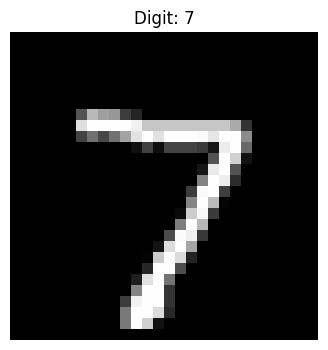


Image saved as:
mnist_sample.png

Upload this file to the Flask application for testing.


In [14]:
# ====================================================
# Step 11: Generate a Sample MNIST Image for Testing
# ====================================================

from torchvision import datasets
import matplotlib.pyplot as plt

# Load MNIST test dataset
mnist_test = datasets.MNIST(
    root="./data",
    train=False,
    download=True
)

# Select sample image
image, label = mnist_test[0]

print("Sample Digit Label")
print("=" * 55)

print(f"True Digit: {label}")

# Display image
plt.figure(figsize=(4, 4))

plt.imshow(
    image,
    cmap="gray"
)

plt.title(
    f"Digit: {label}"
)

plt.axis("off")

plt.show()

# Save image
image.save(
    "mnist_sample.png"
)

print()
print("Image saved as:")
print("mnist_sample.png")

print()
print("Upload this file to the Flask application for testing.")

# Conclusion

In this project, we developed a complete deployment pipeline for a handwritten digit recognition system using PyTorch and Flask. Unlike previous projects that focused primarily on model training and evaluation, this project demonstrated how a trained neural network can be integrated into a web application and accessed through a browser.

The workflow included:

- Recreating the trained neural network architecture
- Loading a saved PyTorch model
- Preprocessing uploaded images
- Performing real-time inference
- Building a Flask-based web interface
- Running the application inside Google Colab
- Generating a browser-accessible deployment URL

This project introduced several important deployment concepts, including model persistence, inference mode, preprocessing consistency, web application development, and user interaction through browser interfaces.

By combining deep learning with Flask, we transformed a trained MNIST classifier into a practical AI application capable of recognizing handwritten digits in real time. This deployment workflow represents a foundational step toward building production-ready machine learning systems and serves as an introduction to modern MLOps and AI application development.